In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

In [2]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

In [3]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [4]:
df.shape

(1200, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [6]:
df.dtypes

,0
age,int64
gender,object
daily_social_media_hours,float64
platform_usage,object
sleep_hours,float64
screen_time_before_sleep,float64
academic_performance,float64
physical_activity,float64
social_interaction_level,object
stress_level,int64


In [7]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [8]:
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [10]:
df['depression_label'].value_counts()

,count
depression_label,
0,1169
1,31


/tmp/ipykernel_1649/1839339103.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='depression_label', palette='Set2', ax=axes[0])


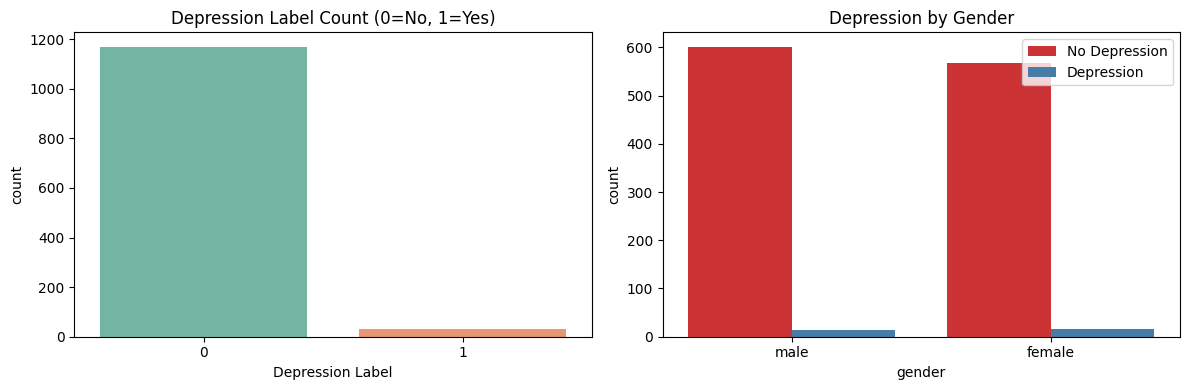

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='depression_label', palette='Set2', ax=axes[0])
axes[0].set_title('Depression Label Count (0=No, 1=Yes)')
axes[0].set_xlabel('Depression Label')

sns.countplot(data=df, x='gender', hue='depression_label', palette='Set1', ax=axes[1])
axes[1].set_title('Depression by Gender')
axes[1].legend(['No Depression', 'Depression'])

plt.tight_layout()
plt.show()

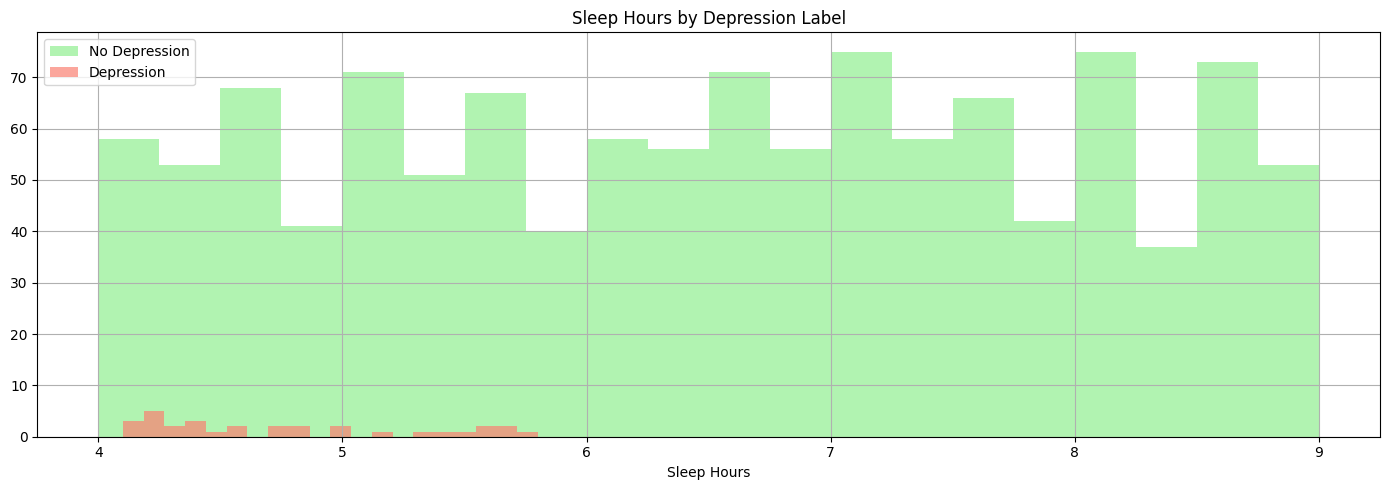

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))

df[df['depression_label']==0]['sleep_hours'].hist(ax=ax, bins=20, alpha=0.7, color='lightgreen', label='No Depression')
df[df['depression_label']==1]['sleep_hours'].hist(ax=ax, bins=20, alpha=0.7, color='salmon', label='Depression')
ax.set_title('Sleep Hours by Depression Label')
ax.set_xlabel('Sleep Hours')
ax.legend()
plt.tight_layout()
plt.show()

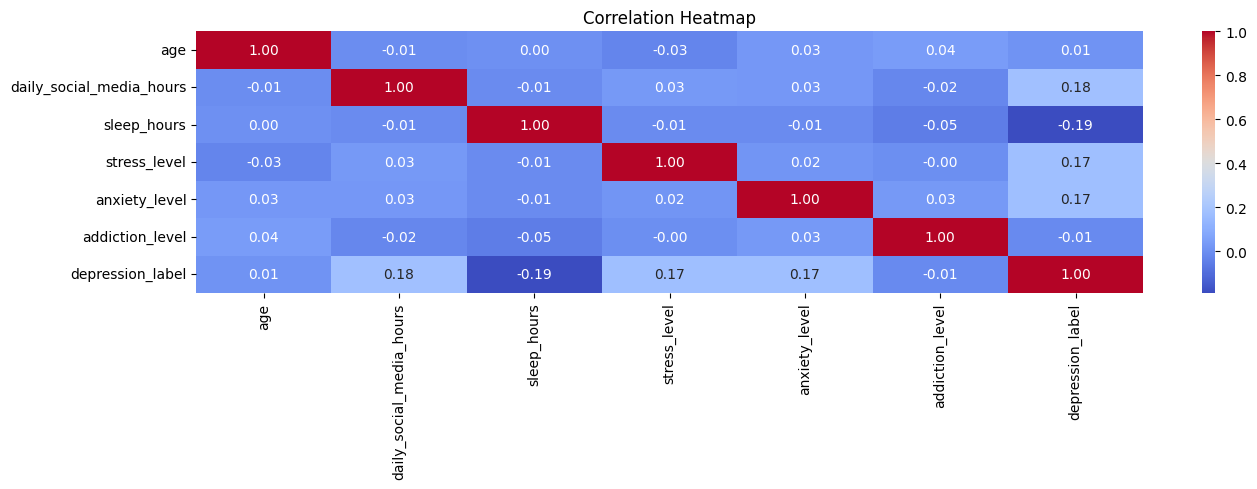

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'stress_level',
            'anxiety_level', 'addiction_level', 'depression_label']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
ax.set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1649/3176624525.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depression_label', y='daily_social_media_hours', palette='Set2', ax=axes[0])
/tmp/ipykernel_1649/3176624525.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='depression_label', y='stress_level', palette='Set1', ax=axes[1])


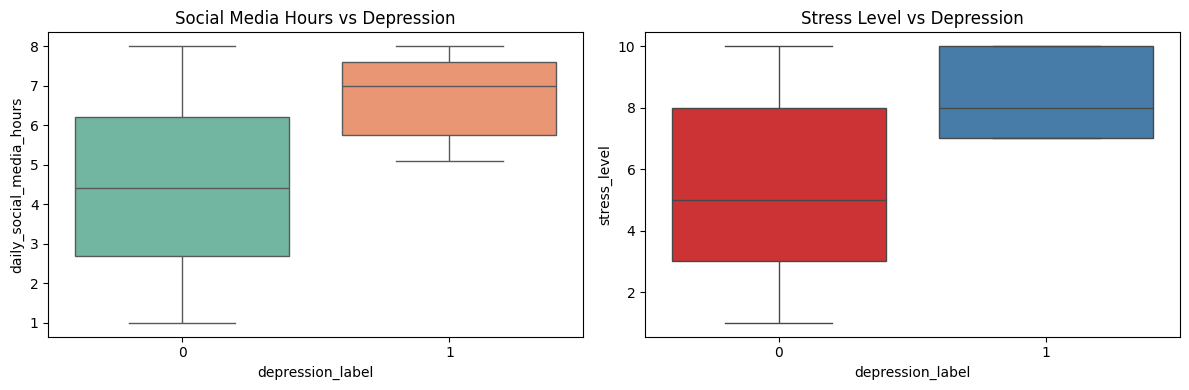

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='depression_label', y='daily_social_media_hours', palette='Set2', ax=axes[0])
axes[0].set_title('Social Media Hours vs Depression')

sns.boxplot(data=df, x='depression_label', y='stress_level', palette='Set1', ax=axes[1])
axes[1].set_title('Stress Level vs Depression')

plt.tight_layout()
plt.show()

In [19]:
for col in ['daily_social_media_hours', 'screen_time_before_sleep']:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)
    print(f"{col} capped at {cap:.2f}")

daily_social_media_hours capped at 8.00
screen_time_before_sleep capped at 3.00


# **Splitting**

In [20]:
X = df.drop(columns=['depression_label'])
y = df['depression_label']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify keeps class ratio
)

In [22]:
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"Train target dist:\n{y_train.value_counts()}")

Train size: (960, 12)
Test size:  (240, 12)
Train target dist:
depression_label
0    935
1     25
Name: count, dtype: int64


In [23]:
numerical_cols = ['age', 'daily_social_media_hours', 'sleep_hours',
                  'screen_time_before_sleep', 'academic_performance',
                  'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']

categorical_cols = ['gender', 'platform_usage']  # no order → OneHotEncoder

ordinal_cols = ['social_interaction_level']       # low < medium < high → OrdinalEncoder

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)
print("Ordinal:", ordinal_cols)

Numerical: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']
Categorical: ['gender', 'platform_usage']
Ordinal: ['social_interaction_level']


# **Preprocessing**

In [24]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['low', 'medium', 'high']]))
])

In [25]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols),
    ('ord', ordinal_pipeline, ordinal_cols)
])

In [26]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

# **Traning Model**

In [27]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'daily_social_media_hours',
                                                   'sleep_hours',
                                                   'screen_time_before_sleep',
                                                   'academic_performance',
                                                   'physical_activity',
                                                   'stress_level',
                                                   'anxiety_level',
                                                   'addiction_level']),
                                                 ('cat',
                                                  Pipeline(ste...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'platform_usage']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high']]))]),
                                                  ['social_interaction_level'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [37]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Rebuild pipeline using imbalanced-learn Pipeline (supports SMOTE)
full_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    # removed class_weight — SMOTE handles it now
])

full_pipeline.fit(X_train, y_train)
print("Model trained with SMOTE ")

Model trained with SMOTE 


# **Evaluate**

In [38]:
y_pred = full_pipeline.predict(X_test)

In [39]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred))

Accuracy : 0.9875
Precision: 1.0
Recall   : 0.5
F1 Score : 0.6667

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       234
           1       1.00      0.50      0.67         6

    accuracy                           0.99       240
   macro avg       0.99      0.75      0.83       240
weighted avg       0.99      0.99      0.99       240



**Confusion Matrix**

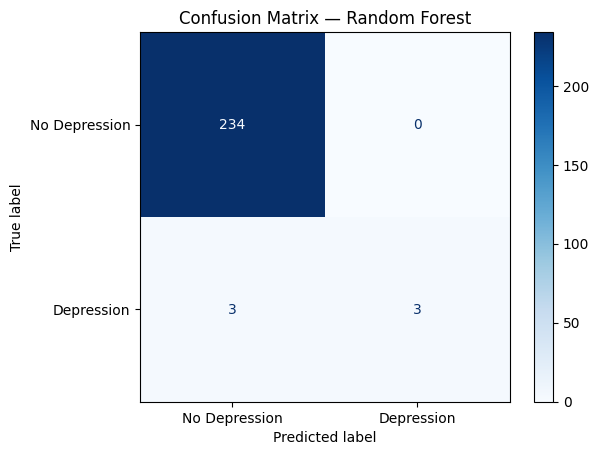

In [40]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Depression', 'Depression'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.show()